# Laplace-Hamming Filter & Segmentation Example 

- **By:** Sarah Elmahdy, 2025 
- **License:** CC-BY 
- **How to cite:** *Specify how you want people to cite this notebook. You can refer to a journal publication or a to repository (to know how to make your code citable by connecting a GitHub repository to Zenodo and get a DOI, read this [blog post](https://docs.github.com/en/repositories/archiving-a-github-repository/referencing-and-citing-content) or watch this [video](https://www.youtube.com/watch?v=gp3D4mf6MHQ))*

---
# Aims

- Demostrate the application of Laplace-Hamming Filter and the segmentation to images.

  **Table of contents**  
  [Step 1: Imports](#imports)   
  [Step 2: Laplace Hamming](#LH)  
  [Step 3: Segmentation of Laplace Hamming Filtered Image](#LHSeg)  

---

<a name="imports"></a>
## *Step 1: Imports:*

Import modules/packages and set the input image path. 

In [1]:
import scipy
import SimpleITK as sitk
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

from scipy.fft import fftshift
from scipy.fft import fftn, ifftn
from ormir_xct.laplace_hamming.laplace_hamming_filter import image_read, segmentation_laplace_hamming

In [2]:
image_file = "images/GRAY_JOINT.nii"
slice_index = 10


<a name="LH"></a>
## *Step 2: Laplace Hamming*

Apply Laplace Hamming filter to the image

In [3]:
# Apply Laplace Hamming filter
filtered_image_np = image_read(image_file)

In [4]:
# Create array of orginal image
image = sitk.ReadImage(image_file)
image_np = sitk.GetArrayFromImage(image)

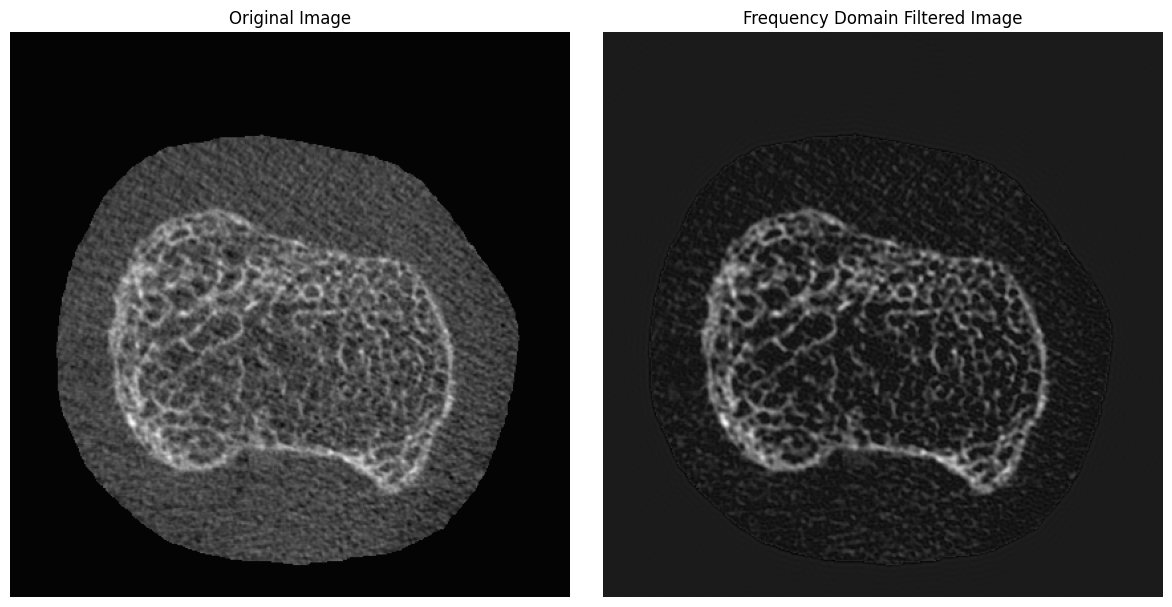

In [5]:
plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(image_np[slice_index, :, :], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(filtered_image_np[slice_index, :, :], cmap="gray")
plt.title("Frequency Domain Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

<a name="LHSeg"></a>
## *Step 3: Segmentation of Laplace Hamming Filtered Image*

Apply segmentation for the Laplace Hamming filter to the image.

In [11]:
# First way is to create the segmented image at the same time with the Laplace Hamming filter
# Can add the lower and upper threshold when calling the function
output = "images/test1.nii"
filtered_segment_image_np = image_read(image_file, True, output)

filtered_segment_image = sitk.ReadImage(output)
filtered_segment_image = sitk.GetArrayFromImage(filtered_segment_image)

In [12]:
# Other way is to call the segmentation function
# Can add the lower and upper threshold when calling the function
output = "images/test2.nii"
segmented_image_np = segmentation_laplace_hamming(image, filtered_image_np, output)

segmented_image = sitk.ReadImage(output)
segmented_image = sitk.GetArrayFromImage(segmented_image)

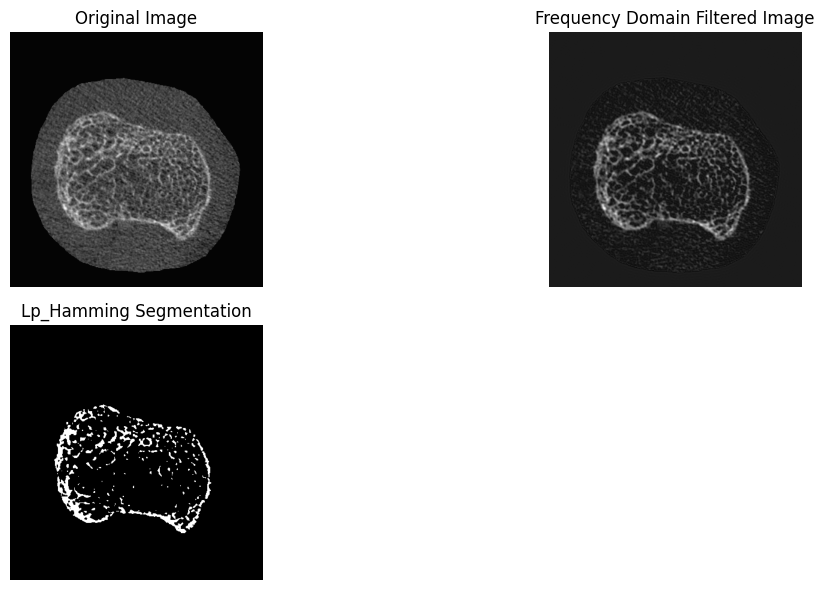

In [16]:
plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(2, 2, 1)
plt.imshow(image_np[slice_index, :, :], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(2, 2, 2)
plt.imshow(filtered_image_np[slice_index, :, :], cmap="gray")
plt.title("Frequency Domain Filtered Image")
plt.axis("off")

# Plot the seg of lp_hamming with the image_read function
plt.subplot(2, 2, 3)
plt.imshow(filtered_segment_image[slice_index, :, :], cmap="gray")
plt.title("Lp_Hamming Segmentation")
plt.axis("off")


plt.tight_layout()
plt.show()

---
<a name="attribution"></a>

Notebook created using the [template](https://github.com/ORMIRcommunity/templates/blob/main/ORMIR_nb_template.ipynb) of the [ORMIR community](https://ormircommunity.github.io/) (version 1.0, 2023)